# 05. Periodos de retorno conjuntos bajo criterios AND y OR (nSPEI-3)

Versión corregida y trazable con los resultados definitivos de los Bloques 03 y 04.

Flujo:

1. Lee los eventos nSPEI-3.
2. Lee las marginales MLE seleccionadas en el Bloque 03.
3. Lee la cópula seleccionada en el Bloque 04 para cada cluster.
4. Reconstruye automáticamente las marginales y las cópulas finales.
5. Calcula las probabilidades conjuntas de excedencia AND y OR.
6. Estima los periodos de retorno usando la definición metodológica de la tesis:
   \(\lambda=N_e/N_a\), con \(N_a=54\) años.
7. Conserva además una tasa normalizada por estación-año como diagnóstico, pero no la usa para los periodos de retorno principales.
8. Evalúa escenarios P50, P75 y P90 y genera superficies de retorno.

Modelos finales esperados:

- Cluster 1: D = LN3, S = LN3, cópula Gaussiana.
- Cluster 2: D = LN3, S = LN3, cópula Gumbel.
- Cluster 3: D = LN3, S = GPA, cópula Gumbel.

Importante: el notebook ya no reestima las marginales mediante momentos-L ni presupone una cópula Gumbel para los tres clusters.


In [92]:
# ============================================================
# 1. LIBRERÍAS
# ============================================================

if (!require("pacman")) install.packages("pacman")

pacman::p_load(
  tidyverse,
  janitor,
  lmomco,
  copula,
  patchwork,
  metR
)


In [93]:
# ============================================================
# 2. RUTAS DEL PROYECTO
# ============================================================

encontrar_raiz_proyecto <- function(inicio = getwd()) {
  marcadores <- c("01_datos", "02_scripts", "03_resultados", "04_documentacion")
  es_raiz <- function(x) all(dir.exists(file.path(x, marcadores)))

  raiz_env <- Sys.getenv("TESIS_SEQUIAS_ROOT", unset = "")
  if (nzchar(raiz_env)) {
    raiz_env <- normalizePath(raiz_env, winslash = "/", mustWork = FALSE)
    if (es_raiz(raiz_env)) return(raiz_env)
  }

  ruta <- normalizePath(inicio, winslash = "/", mustWork = TRUE)

  repeat {
    if (es_raiz(ruta)) return(ruta)

    padre <- dirname(ruta)
    if (identical(padre, ruta)) {
      stop(
        "No se encontró la raíz del proyecto. ",
        "Ejecute Jupyter dentro del repositorio o defina TESIS_SEQUIAS_ROOT."
      )
    }

    ruta <- padre
  }
}

ruta_base <- encontrar_raiz_proyecto()

ruta_procesados <- file.path(
  ruta_base, "01_datos", "procesados"
)

ruta_marginales <- file.path(
  ruta_base, "03_resultados", "03_marginales", "tablas"
)

ruta_copulas <- file.path(
  ruta_base, "03_resultados", "04_copulas", "tablas"
)

ruta_tablas <- file.path(
  ruta_base, "03_resultados", "05_periodos_retorno", "tablas"
)

ruta_figuras <- file.path(
  ruta_base, "03_resultados", "05_periodos_retorno", "figuras"
)

archivo_eventos <- file.path(
  ruta_procesados,
  "eventos_nspei_todas_escalas.csv"
)

archivo_marginales <- file.path(
  ruta_marginales,
  "mejores_marginales_nspei3_por_cluster.csv"
)

archivo_copulas <- file.path(
  ruta_copulas,
  "copulas_seleccionadas_nspei3.csv"
)

dir.create(ruta_tablas, recursive = TRUE, showWarnings = FALSE)
dir.create(ruta_figuras, recursive = TRUE, showWarnings = FALSE)

cat("Eventos:", file.exists(archivo_eventos), "\n")
cat("Marginales:", file.exists(archivo_marginales), "\n")
cat("Cópulas:", file.exists(archivo_copulas), "\n")
cat("Ruta tablas:", ruta_tablas, "\n")
cat("Ruta figuras:", ruta_figuras, "\n")

if (!file.exists(archivo_eventos)) {
  stop("No se encontró el archivo de eventos.")
}

if (!file.exists(archivo_marginales)) {
  stop("No se encontró el archivo de marginales finales del Bloque 03.")
}

if (!file.exists(archivo_copulas)) {
  stop("No se encontró el archivo de cópulas seleccionadas del Bloque 04.")
}


Eventos: TRUE 
Marginales: TRUE 
Cópulas: TRUE 
Ruta tablas: D:/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/05_periodos_retorno/tablas 
Ruta figuras: D:/TESIS_SEQUIAS_UNCP_GITHUB/03_resultados/05_periodos_retorno/figuras 


In [94]:
# ============================================================
# 3. DATOS nSPEI-3 Y LECTURA DE MODELOS FINALES
# ============================================================

eventos <- read.csv(
  archivo_eventos,
  stringsAsFactors = FALSE
) %>%
  clean_names() %>%
  mutate(
    fecha_inicio = as.Date(fecha_inicio),
    fecha_fin = as.Date(fecha_fin),
    cluster_ward = as.integer(cluster_ward)
  )

eventos_3 <- eventos %>%
  filter(escala == "nspei_3") %>%
  filter(
    is.finite(duracion),
    is.finite(severidad),
    duracion > 0,
    severidad > 0
  )

marginales_finales <- read.csv(
  archivo_marginales,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  clean_names() %>%
  mutate(
    cluster = as.integer(stringr::str_extract(grupo, "\\d+")),
    variable_clave = if_else(
      stringr::str_detect(variable, regex("Duraci", ignore_case = TRUE)),
      "D",
      "S"
    ),
    modelo = toupper(modelo)
  )

copulas_finales <- read.csv(
  archivo_copulas,
  stringsAsFactors = FALSE,
  check.names = FALSE
) %>%
  clean_names() %>%
  mutate(
    cluster = as.integer(cluster),
    familia = as.character(familia)
  )

esperado_marginal <- tibble(
  cluster = c(1, 1, 2, 2, 3, 3),
  variable_clave = c("D", "S", "D", "S", "D", "S"),
  modelo_esperado = c("LN3", "LN3", "LN3", "LN3", "LN3", "GPA")
)

verificacion_marginal <- marginales_finales %>%
  select(cluster, variable_clave, modelo) %>%
  left_join(
    esperado_marginal,
    by = c("cluster", "variable_clave")
  ) %>%
  mutate(
    coincide = modelo == modelo_esperado
  )

esperado_copula <- tibble(
  cluster = 1:3,
  familia_esperada = c("Gaussian", "Gumbel", "Gumbel")
)

verificacion_copula <- copulas_finales %>%
  select(cluster, familia, convergio, coincide_aic_bic) %>%
  left_join(
    esperado_copula,
    by = "cluster"
  ) %>%
  mutate(
    coincide = familia == familia_esperada
  )

cat("\n=== VERIFICACIÓN DE MARGINALES ===\n")
print(verificacion_marginal)

cat("\n=== VERIFICACIÓN DE CÓPULAS ===\n")
print(verificacion_copula)

if (any(is.na(verificacion_marginal$coincide) | !verificacion_marginal$coincide)) {
  stop("Las marginales no coinciden con los resultados definitivos del Bloque 03.")
}

if (
  any(is.na(verificacion_copula$coincide) | !verificacion_copula$coincide) ||
  any(!verificacion_copula$convergio) ||
  any(!verificacion_copula$coincide_aic_bic)
) {
  stop("Las cópulas no coinciden con los resultados definitivos del Bloque 04.")
}



=== VERIFICACIÓN DE MARGINALES ===
  cluster variable_clave modelo modelo_esperado coincide
1       1              D    LN3             LN3     TRUE
2       1              S    LN3             LN3     TRUE
3       2              D    LN3             LN3     TRUE
4       2              S    LN3             LN3     TRUE
5       3              D    LN3             LN3     TRUE
6       3              S    GPA             GPA     TRUE

=== VERIFICACIÓN DE CÓPULAS ===
  cluster  familia convergio coincide_aic_bic familia_esperada coincide
1       1 Gaussian      TRUE             TRUE         Gaussian     TRUE
2       2   Gumbel      TRUE             TRUE           Gumbel     TRUE
3       3   Gumbel      TRUE             TRUE           Gumbel     TRUE


In [95]:
# ============================================================
# 4. RECONSTRUCCIÓN DE MARGINALES Y CÓPULAS
# ============================================================

parsear_parametros_marginal <- function(x) {
  as.numeric(trimws(strsplit(x, ",", fixed = TRUE)[[1]]))
}

obtener_marginal <- function(cluster, variable_clave) {

  fila <- marginales_finales %>%
    filter(
      .data$cluster == .env$cluster,
      .data$variable_clave == .env$variable_clave
    )

  if (nrow(fila) != 1) {
    stop(
      "No se encontró exactamente una marginal para cluster ",
      cluster, " y variable ", variable_clave
    )
  }

  tipo <- tolower(fila$modelo[[1]])
  pars <- parsear_parametros_marginal(fila$parametros[[1]])

  list(
    modelo = toupper(tipo),
    parametros = pars,
    par_obj = lmomco::vec2par(pars, type = tipo)
  )
}

parsear_parametros_copula <- function(x) {

  piezas <- strsplit(x, ";", fixed = TRUE)[[1]]

  valores <- vapply(
    piezas,
    function(z) {
      partes <- strsplit(z, "=", fixed = TRUE)[[1]]
      if (length(partes) < 2) return(NA_real_)
      as.numeric(trimws(partes[length(partes)]))
    },
    numeric(1)
  )

  if (any(!is.finite(valores))) {
    stop("No se pudieron interpretar los parámetros de la cópula: ", x)
  }

  valores
}

obtener_copula <- function(cluster) {

  fila <- copulas_finales %>%
    filter(.data$cluster == .env$cluster)

  if (nrow(fila) != 1) {
    stop("No se encontró exactamente una cópula para el cluster ", cluster)
  }

  familia <- fila$familia[[1]]
  pars <- parsear_parametros_copula(fila$parametro[[1]])

  cop <- switch(
    tolower(familia),

    "gaussian" = normalCopula(
      param = pars[1],
      dim = 2,
      dispstr = "un"
    ),

    "gumbel" = gumbelCopula(
      param = pars[1],
      dim = 2
    ),

    "clayton" = claytonCopula(
      param = pars[1],
      dim = 2
    ),

    "frank" = frankCopula(
      param = pars[1],
      dim = 2
    ),

    "t-student" = tCopula(
      param = pars[1],
      dim = 2,
      dispstr = "un",
      df = pars[2],
      df.fixed = TRUE
    ),

    stop("Familia de cópula no implementada: ", familia)
  )

  list(
    familia = familia,
    parametro_texto = fila$parametro[[1]],
    parametros = pars,
    copula = cop
  )
}

modelos_cluster <- lapply(
  1:3,
  function(cl) {
    list(
      cluster = cl,
      D = obtener_marginal(cl, "D"),
      S = obtener_marginal(cl, "S"),
      C = obtener_copula(cl)
    )
  }
)

tabla_modelos_finales <- map_dfr(
  modelos_cluster,
  function(m) {
    tibble(
      cluster = m$cluster,
      marginal_duracion = m$D$modelo,
      marginal_severidad = m$S$modelo,
      copula = m$C$familia,
      parametro_copula = m$C$parametro_texto
    )
  }
)

tabla_modelos_finales


cluster,marginal_duracion,marginal_severidad,copula,parametro_copula
<int>,<chr>,<chr>,<chr>,<chr>
1,LN3,LN3,Gaussian,rho.1=0.903663
2,LN3,LN3,Gumbel,alpha=3.456922
3,LN3,GPA,Gumbel,alpha=3.801567


In [96]:
# ============================================================
# 5. FUNCIONES DE PROBABILIDAD Y PERIODO DE RETORNO
# ============================================================

cdf_marginal <- function(x, par_obj, eps = 1e-8) {
  p <- lmomco::plmomco(x, par_obj)

  if (any(!is.finite(p))) {
    stop("Se obtuvieron valores no finitos en una CDF marginal.")
  }

  pmin(pmax(p, eps), 1 - eps)
}

prob_and_or <- function(d, s, par_d, par_s, copula_obj) {

  u <- cdf_marginal(d, par_d)
  v <- cdf_marginal(s, par_s)

  Cuv <- copula::pCopula(
    cbind(u, v),
    copula_obj
  )

  p_and <- 1 - u - v + Cuv
  p_or  <- 1 - Cuv

  # Protección frente a errores de redondeo de punto flotante.
  p_and <- pmin(pmax(p_and, 0), 1)
  p_or  <- pmin(pmax(p_or, 0), 1)

  tibble(
    d = d,
    s = s,
    u = u,
    v = v,
    Cuv = Cuv,
    p_and = p_and,
    p_or = p_or
  )
}

retorno_and_or <- function(
  d, s,
  par_d, par_s,
  copula_obj,
  lambda_eventos,
  eps_prob = 1e-15
) {

  prob_and_or(
    d = d,
    s = s,
    par_d = par_d,
    par_s = par_s,
    copula_obj = copula_obj
  ) %>%
    mutate(
      T_and = 1 / (lambda_eventos * pmax(p_and, eps_prob)),
      T_or  = 1 / (lambda_eventos * pmax(p_or, eps_prob))
    )
}


In [97]:
# ============================================================
# 6. TASAS DE OCURRENCIA Y ESCENARIOS P50-P75-P90
# ============================================================

N_ANIOS <- 54

procesar_cluster_retorno <- function(
  datos_cluster,
  cluster_id,
  modelo_cluster,
  N_anios = N_ANIOS
) {

  n_eventos <- nrow(datos_cluster)
  n_estaciones <- n_distinct(datos_cluster$estacion)

  # Definición utilizada en la metodología de la tesis:
  lambda_cluster <- n_eventos / N_anios

  # Se conserva solo como diagnóstico para evaluar el efecto
  # del diferente número de estaciones entre clusters.
  lambda_estacion_anio <- n_eventos / (N_anios * n_estaciones)

  lambda_retorno <- lambda_estacion_anio

  perc_d <- quantile(
    datos_cluster$duracion,
    probs = c(0.50, 0.75, 0.90),
    na.rm = TRUE,
    type = 7
  )

  perc_s <- quantile(
    datos_cluster$severidad,
    probs = c(0.50, 0.75, 0.90),
    na.rm = TRUE,
    type = 7
  )

  niveles <- c("P50", "P75", "P90")

  tabla_d <- tibble(
    percentil_d = niveles,
    d = as.numeric(perc_d)
  )

  tabla_s <- tibble(
    percentil_s = niveles,
    s = as.numeric(perc_s)
  )

  grid <- tidyr::crossing(
    tabla_d,
    tabla_s
  )

  probs <- retorno_and_or(
    d = grid$d,
    s = grid$s,
    par_d = modelo_cluster$D$par_obj,
    par_s = modelo_cluster$S$par_obj,
    copula_obj = modelo_cluster$C$copula,
    lambda_eventos = lambda_retorno
  )

  tabla_ret <- bind_cols(
    grid,
    probs %>% select(u, v, Cuv, p_and, p_or, T_and, T_or)
  ) %>%
    mutate(
      cluster = cluster_id,
      dist_d = modelo_cluster$D$modelo,
      dist_s = modelo_cluster$S$modelo,
      copula = modelo_cluster$C$familia,
      parametro_copula = modelo_cluster$C$parametro_texto,
      n_eventos = n_eventos,
      n_estaciones = n_estaciones,
      n_anios = N_anios,
      lambda_cluster = lambda_cluster,
      lambda_estacion_anio = lambda_estacion_anio
    )

  list(
    tabla = tabla_ret,
    lambda_cluster = lambda_cluster,
    lambda_estacion_anio = lambda_estacion_anio,
    n_eventos = n_eventos,
    n_estaciones = n_estaciones
  )
}

datos_clusters <- lapply(
  1:3,
  function(cl) {
    eventos_3 %>%
      filter(cluster_ward == cl)
  }
)

resultados_cluster <- lapply(
  1:3,
  function(cl) {
    procesar_cluster_retorno(
      datos_cluster = datos_clusters[[cl]],
      cluster_id = cl,
      modelo_cluster = modelos_cluster[[cl]]
    )
  }
)

retornos_all <- bind_rows(
  lapply(resultados_cluster, `[[`, "tabla")
) %>%
  arrange(cluster, percentil_d, percentil_s)

tabla_tasas <- map_dfr(
  1:3,
  function(cl) {
    r <- resultados_cluster[[cl]]
    tibble(
      cluster = cl,
      n_eventos = r$n_eventos,
      n_estaciones = r$n_estaciones,
      n_anios = N_ANIOS,
      lambda_cluster = r$lambda_cluster,
      lambda_estacion_anio = r$lambda_estacion_anio
    )
  }
)

write.csv(
  retornos_all,
  file.path(ruta_tablas, "retornos_and_or_nspei3_tres_clusters.csv"),
  row.names = FALSE
)

write.csv(
  tabla_tasas,
  file.path(ruta_tablas, "diagnostico_tasas_eventos_nspei3.csv"),
  row.names = FALSE
)

cat("\n=== TASAS DE OCURRENCIA ===\n")
print(tabla_tasas)

cat("\n=== 27 ESCENARIOS P50-P75-P90 ===\n")
print(
  retornos_all %>%
    select(
      cluster,
      percentil_d,
      percentil_s,
      d,
      s,
      dist_d,
      dist_s,
      copula,
      lambda_cluster,
      u,
      v,
      Cuv,
      p_and,
      p_or,
      T_and,
      T_or
    ),
  n = Inf,
  width = Inf
)



=== TASAS DE OCURRENCIA ===
# A tibble: 3 × 6
  cluster n_eventos n_estaciones n_anios lambda_cluster lambda_estacion_anio
    <int>     <int>        <int>   <dbl>          <dbl>                <dbl>
1       1       584           18      54          10.8                 0.601
2       2       152            6      54           2.81                0.469
3       3        61            4      54           1.13                0.282

=== 27 ESCENARIOS P50-P75-P90 ===
# A tibble: 27 × 16
   cluster percentil_d percentil_s     d     s dist_d dist_s copula  
     <int> <chr>       <chr>       <dbl> <dbl> <chr>  <chr>  <chr>   
 1       1 P50         P50           6    5.15 LN3    LN3    Gaussian
 2       1 P50         P75           6    8.48 LN3    LN3    Gaussian
 3       1 P50         P90           6   12.9  LN3    LN3    Gaussian
 4       1 P75         P50           8    5.15 LN3    LN3    Gaussian
 5       1 P75         P75           8    8.48 LN3    LN3    Gaussian
 6       1 P75         

In [98]:
# ============================================================
# 7. TABLA PRINCIPAL - ESCENARIOS P90-P90
# ============================================================

tabla_14 <- retornos_all %>%
  filter(
    percentil_d == "P90",
    percentil_s == "P90"
  ) %>%
  transmute(
    cluster,
    d,
    s,
    dist_d,
    dist_s,
    copula,
    parametro_copula,
    lambda_estacion_anio = lambda_estacion_anio,
    u,
    v,
    `C(u,v)` = Cuv,
    p_AND = p_and,
    p_OR = p_or,
    T_AND = T_and,
    T_OR = T_or
  )

write.csv(
  tabla_14,
  file.path(ruta_tablas, "tabla_14_escenarios_representativos_retornos.csv"),
  row.names = FALSE
)

cat("\n=== ESCENARIOS REPRESENTATIVOS P90-P90 ===\n")
print(tabla_14, n = Inf, width = Inf)



=== ESCENARIOS REPRESENTATIVOS P90-P90 ===
# A tibble: 3 × 15
  cluster     d     s dist_d dist_s copula   parametro_copula
    <int> <dbl> <dbl> <chr>  <chr>  <chr>    <chr>           
1       1  12    12.9 LN3    LN3    Gaussian rho.1=0.903663  
2       2  17.9  17.9 LN3    LN3    Gumbel   alpha=3.456922  
3       3  28    34.9 LN3    GPA    Gumbel   alpha=3.801567  
  lambda_estacion_anio     u     v `C(u,v)`  p_AND  p_OR T_AND  T_OR
                 <dbl> <dbl> <dbl>    <dbl>  <dbl> <dbl> <dbl> <dbl>
1                0.601 0.891 0.895    0.861 0.0750 0.139  22.2  11.9
2                0.469 0.912 0.901    0.887 0.0731 0.113  29.1  18.8
3                0.282 0.863 0.911    0.857 0.0837 0.143  42.3  24.8


In [99]:
# ============================================================
# 8. DEFINICIÓN PROBABILÍSTICA AND / OR
# ============================================================

tabla_15 <- tibble(
  criterio = c("AND", "OR"),
  condicion = c(
    "D > d ∩ S > s",
    "D > d ∪ S > s"
  ),
  probabilidad = c(
    "1 - u - v + C(u,v)",
    "1 - C(u,v)"
  ),
  interpretacion = c(
    "Ambos umbrales son excedidos simultáneamente",
    "Al menos uno de los dos umbrales es excedido"
  )
)

write.csv(
  tabla_15,
  file.path(ruta_tablas, "tabla_15_definicion_probabilistica_retornos.csv"),
  row.names = FALSE
)

tabla_15


criterio,condicion,probabilidad,interpretacion
<chr>,<chr>,<chr>,<chr>
AND,D > d ∩ S > s,"1 - u - v + C(u,v)",Ambos umbrales son excedidos simultáneamente
OR,D > d ∪ S > s,"1 - C(u,v)",Al menos uno de los dos umbrales es excedido


In [100]:
# ============================================================
# 9. MALLAS PARA LAS SUPERFICIES DE RETORNO
# ============================================================

malla_retornos <- function(
  datos_cluster,
  modelo_cluster,
  lambda_eventos,
  cluster_label,
  n_d = 80,
  n_s = 80
) {

  d_seq <- seq(
    min(datos_cluster$duracion, na.rm = TRUE),
    as.numeric(quantile(datos_cluster$duracion, 0.95, na.rm = TRUE)),
    length.out = n_d
  )

  s_seq <- seq(
    min(datos_cluster$severidad, na.rm = TRUE),
    as.numeric(quantile(datos_cluster$severidad, 0.95, na.rm = TRUE)),
    length.out = n_s
  )

  grid <- expand.grid(
    d = d_seq,
    s = s_seq
  ) %>%
    as_tibble()

  ret <- retorno_and_or(
    d = grid$d,
    s = grid$s,
    par_d = modelo_cluster$D$par_obj,
    par_s = modelo_cluster$S$par_obj,
    copula_obj = modelo_cluster$C$copula,
    lambda_eventos = lambda_eventos
  )

  bind_cols(
    grid,
    ret %>% select(T_and, T_or)
  ) %>%
    mutate(
      cluster = cluster_label,
      copula = modelo_cluster$C$familia
    )
}

mallas <- lapply(
  1:3,
  function(cl) {
    malla_retornos(
      datos_cluster = datos_clusters[[cl]],
      modelo_cluster = modelos_cluster[[cl]],
      lambda_eventos = resultados_cluster[[cl]]$lambda_estacion_anio,
      cluster_label = paste("Cluster", cl)
    )
  }
)

cat("Mallas generadas correctamente.\n")


Mallas generadas correctamente.


In [101]:
# ============================================================
# 10. FUNCIÓN GRÁFICA AND / OR CON P50, P75 Y P90
# ============================================================

library(ggplot2)
library(dplyr)
library(metR)
library(scales)
library(viridisLite)

# Paleta sofisticada tipo magma


pal_sequia <- c(
  "#17324D",  # azul profundo: retorno bajo
  "#4F81A8",
  "#A7C0D9",
  "#F3E9DC",  # transición neutra
  "#D98E73",
  "#C44536",
  "#8C1D18"   # rojo vino: retorno alto
)

extraer_percentiles <- function(datos_cluster) {
  tibble(
    percentil = c("P50", "P75", "P90"),
    d = as.numeric(
      quantile(
        datos_cluster$duracion,
        probs = c(0.50, 0.75, 0.90),
        na.rm = TRUE,
        type = 7
      )
    ),
    s = as.numeric(
      quantile(
        datos_cluster$severidad,
        probs = c(0.50, 0.75, 0.90),
        na.rm = TRUE,
        type = 7
      )
    )
  )
}

plot_retorno <- function(
  malla_df,
  datos_cluster,
  cluster_label,
  familia_copula,
  tipo = c("AND", "OR")
) {

  tipo <- match.arg(tipo)

  # Nombre de la cópula en español
  nombre_copula <- dplyr::case_when(
    familia_copula == "Gaussian"  ~ "Gaussiana",
    familia_copula == "Gumbel"    ~ "Gumbel",
    familia_copula == "Clayton"   ~ "Clayton",
    familia_copula == "Frank"     ~ "Frank",
    familia_copula == "t-Student" ~ "t de Student",
    TRUE ~ familia_copula
  )

  percs <- extraer_percentiles(datos_cluster)

  if (tipo == "AND") {
    zvar <- "T_and"
    titulo <- paste0(cluster_label, " | Periodo de retorno conjunto tipo AND")
    legend_lab <- expression(T[AND]~"(años)")
  } else {
    zvar <- "T_or"
    titulo <- paste0(cluster_label, " | Periodo de retorno conjunto tipo OR")
    legend_lab <- expression(T[OR]~"(años)")
  }

  rango <- range(malla_df[[zvar]], na.rm = TRUE)
  brks <- pretty(rango, n = 6)
  brks <- brks[brks >= rango[1] & brks <= rango[2]]

  xmin <- min(malla_df$d, na.rm = TRUE)
  xmax <- max(malla_df$d, na.rm = TRUE)
  ymin <- min(malla_df$s, na.rm = TRUE)
  ymax <- max(malla_df$s, na.rm = TRUE)

  ggplot(malla_df, aes(x = d, y = s)) +
    geom_raster(
      aes(fill = .data[[zvar]]),
      interpolate = TRUE
    ) +
    geom_contour(
      aes(z = .data[[zvar]]),
      breaks = brks,
      colour = "#1F4E79",
      linewidth = 0.55,
      alpha = 0.95
    ) +
    metR::geom_text_contour(
      aes(z = .data[[zvar]]),
      breaks = brks,
      colour = "#1F4E79",
      stroke = 0.15,
      size = 3.2,
      check_overlap = TRUE
    ) +
    geom_vline(
      data = percs,
      aes(xintercept = d),
      linetype = "22",
      linewidth = 0.45,
      colour = "#4A4A4A",
      alpha = 0.9
    ) +
    geom_hline(
      data = percs,
      aes(yintercept = s),
      linetype = "22",
      linewidth = 0.45,
      colour = "#4A4A4A",
      alpha = 0.9
    ) +
    geom_label(
      data = percs,
      aes(x = d, y = ymin, label = percentil),
      inherit.aes = FALSE,
      size = 3.1,
      vjust = 1.35,
      label.size = 0.15,
      fill = alpha("white", 0.80),
      colour = "#2F2F2F"
    ) +
    geom_label(
      data = percs,
      aes(x = xmin, y = s, label = percentil),
      inherit.aes = FALSE,
      size = 3.1,
      hjust = -0.10,
      label.size = 0.15,
      fill = alpha("white", 0.80),
      colour = "#2F2F2F"
    ) +
    scale_fill_gradientn(
      colours = pal_sequia,
      name = legend_lab,
      breaks = brks,
      labels = label_number(accuracy = 0.1),
      guide = guide_colorbar(
        barheight = unit(8, "cm"),
        barwidth  = unit(0.7, "cm"),
        frame.colour = "#666666",
        ticks.colour = "#666666"
      )
    ) +
    coord_cartesian(expand = FALSE) +
    labs(
      title = titulo,
      subtitle = paste0("nSPEI-3 | Cópula ", nombre_copula),
      x = "Duración (meses)",
      y = "Severidad acumulada"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      plot.title = element_text(
        face = "bold",
        size = 15,
        hjust = 0.5,
        margin = margin(b = 5)
      ),
      plot.subtitle = element_text(
        size = 11.5,
        hjust = 0.5,
        colour = "#3C3C3C",
        margin = margin(b = 10)
      ),
      axis.title = element_text(face = "bold", size = 12.5),
      axis.text = element_text(size = 10.5, colour = "#333333"),
      panel.grid.major = element_line(colour = "#DDDDDD", linewidth = 0.35),
      panel.grid.minor = element_blank(),
      panel.border = element_rect(colour = "#BEBEBE", fill = NA, linewidth = 0.5),
      legend.position = "right",
      legend.title = element_text(face = "bold", size = 11),
      legend.text = element_text(size = 10),
      plot.background = element_rect(fill = "white", colour = NA),
      panel.background = element_rect(fill = "white", colour = NA)
    )
}

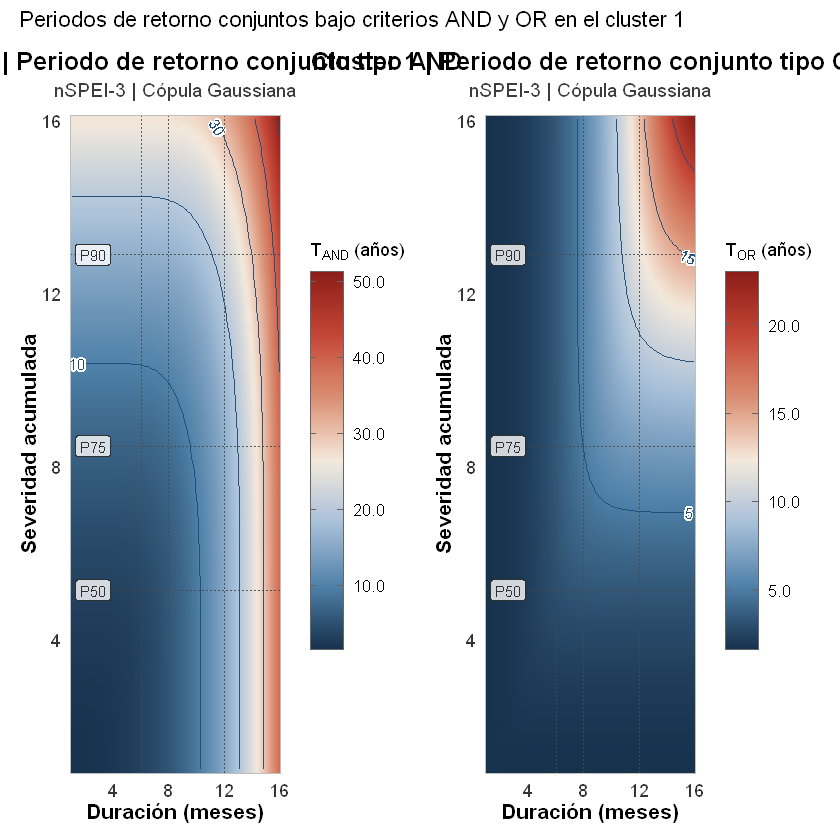

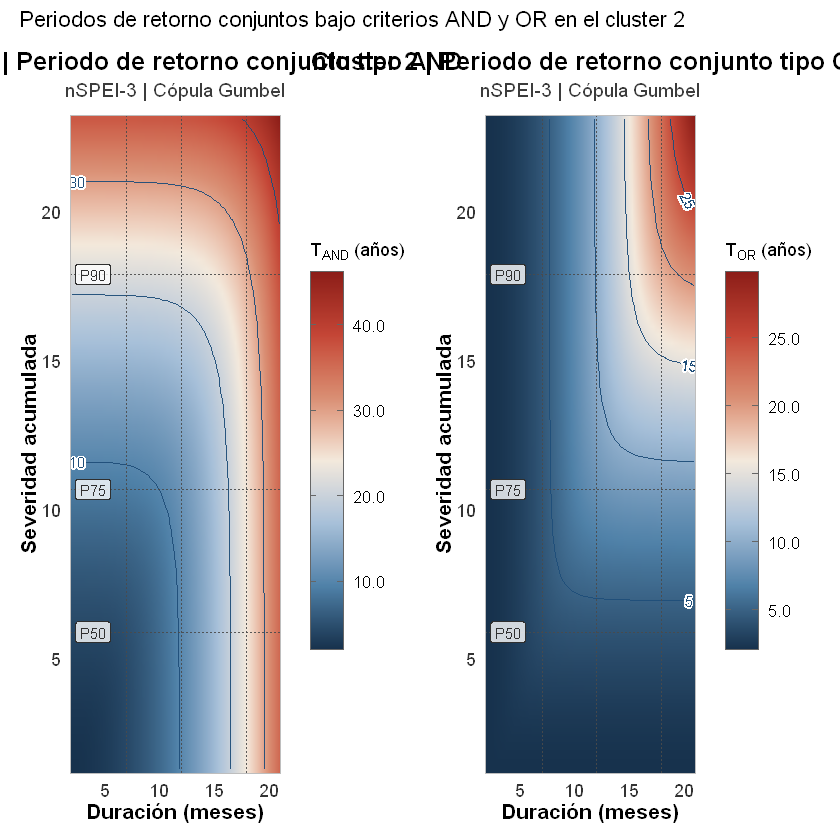

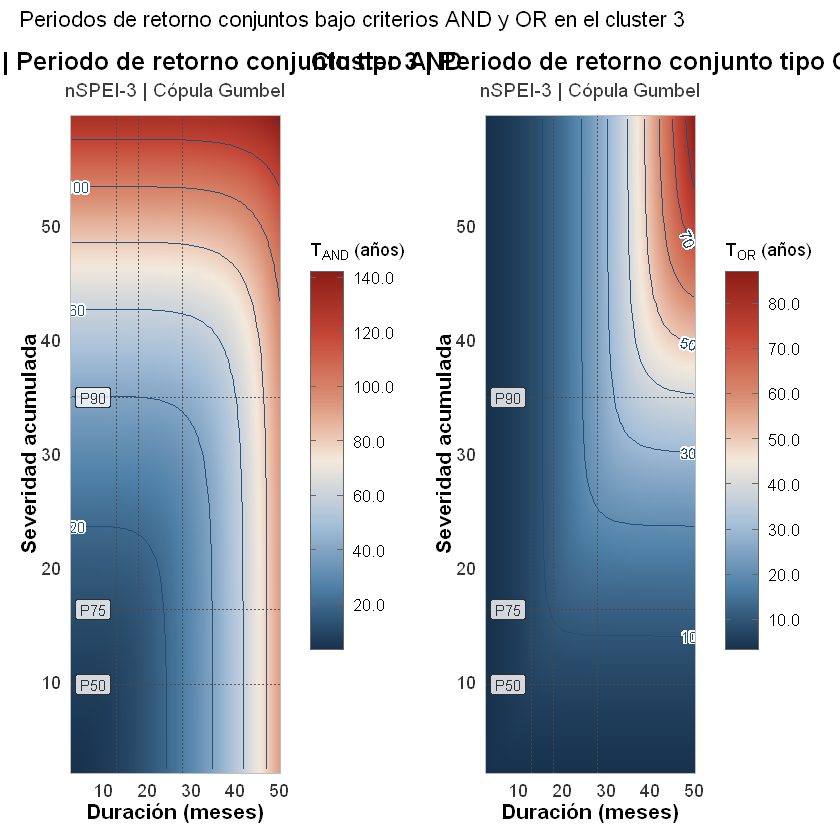

In [102]:
# ============================================================
# 11. FIGURAS DE PERIODOS DE RETORNO POR CLUSTER
# ============================================================

plots <- vector("list", 3)

for (cl in 1:3) {

  familia <- modelos_cluster[[cl]]$C$familia

  p_and <- plot_retorno(
    mallas[[cl]],
    datos_clusters[[cl]],
    paste("Cluster", cl),
    familia,
    "AND"
  )

  p_or <- plot_retorno(
    mallas[[cl]],
    datos_clusters[[cl]],
    paste("Cluster", cl),
    familia,
    "OR"
  )

  figura <- (p_and | p_or) +
    plot_annotation(
      title = paste0(
        "Periodos de retorno conjuntos bajo criterios AND y OR en el cluster ",
        cl
      )
    )

  plots[[cl]] <- list(
    AND = p_and,
    OR = p_or,
    combinada = figura
  )

  # Archivos separados: compatibles con las rutas actualmente usadas en LaTeX.
  ggsave(
    file.path(
      ruta_figuras,
      paste0("retorno_AND_cluster", cl, "_q1.png")
    ),
    p_and,
    width = 6.6,
    height = 5.6,
    dpi = 400,
    bg = "white"
  )

  ggsave(
    file.path(
      ruta_figuras,
      paste0("retorno_OR_cluster", cl, "_q1.png")
    ),
    p_or,
    width = 6.6,
    height = 5.6,
    dpi = 400,
    bg = "white"
  )

  # Archivo combinado adicional.
  ggsave(
    file.path(
      ruta_figuras,
      paste0("figura_", 16 + cl, "_retornos_and_or_cluster", cl, ".png")
    ),
    figura,
    width = 13.5,
    height = 5.8,
    dpi = 400,
    bg = "white"
  )

  print(figura)
}


In [103]:
# ============================================================
# 12. CONTROLES NUMÉRICOS Y VERIFICACIÓN FINAL
# ============================================================

control_logico <- retornos_all %>%
  transmute(
    cluster,
    percentil_d,
    percentil_s,
    p_and,
    p_or,
    T_and,
    T_or,
    cumple_p_and_menor_igual_p_or = p_and <= p_or + 1e-12,
    cumple_t_and_mayor_igual_t_or = T_and + 1e-12 >= T_or
  )

if (
  any(!control_logico$cumple_p_and_menor_igual_p_or) ||
  any(!control_logico$cumple_t_and_mayor_igual_t_or)
) {
  stop("Se detectó una inconsistencia lógica entre AND y OR.")
}

salidas <- c(
  file.path(ruta_tablas, "retornos_and_or_nspei3_tres_clusters.csv"),
  file.path(ruta_tablas, "tabla_14_escenarios_representativos_retornos.csv"),
  file.path(ruta_tablas, "tabla_15_definicion_probabilistica_retornos.csv"),
  file.path(ruta_tablas, "diagnostico_tasas_eventos_nspei3.csv"),
  file.path(ruta_figuras, "retorno_AND_cluster1_q1.png"),
  file.path(ruta_figuras, "retorno_OR_cluster1_q1.png"),
  file.path(ruta_figuras, "retorno_AND_cluster2_q1.png"),
  file.path(ruta_figuras, "retorno_OR_cluster2_q1.png"),
  file.path(ruta_figuras, "retorno_AND_cluster3_q1.png"),
  file.path(ruta_figuras, "retorno_OR_cluster3_q1.png"),
  file.path(ruta_figuras, "figura_17_retornos_and_or_cluster1.png"),
  file.path(ruta_figuras, "figura_18_retornos_and_or_cluster2.png"),
  file.path(ruta_figuras, "figura_19_retornos_and_or_cluster3.png")
)

verificacion <- tibble(
  archivo = basename(salidas),
  existe = file.exists(salidas),
  tamaño_bytes = file.info(salidas)$size
)

cat("\n=== CONTROL P90-P90 ===\n")
print(tabla_14, n = Inf, width = Inf)

cat("\n=== CONTROL LÓGICO AND / OR ===\n")
print(
  control_logico %>%
    summarise(
      todos_p_and_menor_igual_p_or = all(cumple_p_and_menor_igual_p_or),
      todos_t_and_mayor_igual_t_or = all(cumple_t_and_mayor_igual_t_or)
    )
)

cat("\n=== ARCHIVOS GENERADOS ===\n")
print(verificacion, n = Inf, width = Inf)

cat(
  "\nNOTA: lambda_cluster = N_eventos / 54 es la definición usada en la metodología ",
  "actual de la tesis. Como los clusters contienen distinto número de estaciones, ",
  "las comparaciones directas de magnitud de T entre clusters deben interpretarse ",
  "con cautela. La columna lambda_estacion_anio se conserva como diagnóstico.\n"
)



=== CONTROL P90-P90 ===
# A tibble: 3 × 15
  cluster     d     s dist_d dist_s copula   parametro_copula
    <int> <dbl> <dbl> <chr>  <chr>  <chr>    <chr>           
1       1  12    12.9 LN3    LN3    Gaussian rho.1=0.903663  
2       2  17.9  17.9 LN3    LN3    Gumbel   alpha=3.456922  
3       3  28    34.9 LN3    GPA    Gumbel   alpha=3.801567  
  lambda_estacion_anio     u     v `C(u,v)`  p_AND  p_OR T_AND  T_OR
                 <dbl> <dbl> <dbl>    <dbl>  <dbl> <dbl> <dbl> <dbl>
1                0.601 0.891 0.895    0.861 0.0750 0.139  22.2  11.9
2                0.469 0.912 0.901    0.887 0.0731 0.113  29.1  18.8
3                0.282 0.863 0.911    0.857 0.0837 0.143  42.3  24.8

=== CONTROL LÓGICO AND / OR ===
# A tibble: 1 × 2
  todos_p_and_menor_igual_p_or todos_t_and_mayor_igual_t_or
  <lgl>                        <lgl>                       
1 TRUE                         TRUE                        

=== ARCHIVOS GENERADOS ===
# A tibble: 13 × 3
   archivo             